<a href="https://colab.research.google.com/github/Harshitha2807/smart-meter-energy-forecasting/blob/main/smart_meter_energy_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import requests
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import datetime, timedelta

print('All imports OK')

All imports OK


In [6]:
# ── CONFIG — change only this cell ───────────────────────────────────────
CONSUMER_API_BASE = 'https://ap.elementsenergies.com/api/fetchHConsWAvg'
MSN         = '67000709'                           # target consumer MSN
TRAIN_START = '2025-01-01'                         # training window start
TODAY       = datetime.now().strftime('%Y-%m-%d')  # auto-detects today's date

# Detect the last available hour from the API
# (do NOT use datetime.now().hour — local clock and API timezone may differ)
_probe = requests.get(CONSUMER_API_BASE,
                      params={'startdate': TODAY, 'enddate': TODAY, 'msn': MSN},
                      timeout=60).json()
_today_hours = [int(rec['hour'].split(':')[0]) for rec in _probe['data']]
CURRENT_HOUR = max(_today_hours) if _today_hours else 0

print(f'Consumer    : {MSN}')
print(f'Train from  : {TRAIN_START}  →  {TODAY}')
print(f'Current     : {TODAY} {CURRENT_HOUR:02d}:00  (detected from API)')
print(f'Will predict: {CURRENT_HOUR + 1:02d}:00 – 23:00  ({23 - CURRENT_HOUR} hours remaining)')

Consumer    : 67000709
Train from  : 2025-01-01  →  2026-06-24
Current     : 2026-06-24 00:00  (detected from API)
Will predict: 01:00 – 23:00  (23 hours remaining)


In [7]:
def fetch_consumption_data(msn: str, start_date: str, end_date: str) -> pd.DataFrame:
    params   = {'startdate': start_date, 'enddate': end_date, 'msn': msn}
    resp     = requests.get(CONSUMER_API_BASE, params=params, timeout=120)
    resp.raise_for_status()
    payload  = resp.json()
    raw_data = payload['data']
    rows     = []

    if isinstance(raw_data, dict):
        for date_str, hour_list in raw_data.items():
            if isinstance(hour_list, list):
                for rec in hour_list:
                    try:
                        rows.append({
                            'ds': pd.to_datetime(date_str + ' ' + rec['hour']),
                            'y' : float(rec['consumption'])
                        })
                    except Exception as e:
                        print(f'  [WARN] skipped: {rec} — {e}')
            elif isinstance(hour_list, dict):
                try:
                    rows.append({
                        'ds': pd.to_datetime(date_str + ' ' + hour_list['hour']),
                        'y' : float(hour_list['consumption'])
                    })
                except Exception as e:
                    print(f'  [WARN] skipped: {hour_list} — {e}')

    elif isinstance(raw_data, list):
        # ── Single-day fetch: API returns only hour+consumption, no date field ──
        # Use start_date as the date for all records
        for rec in raw_data:
            try:
                hour_val = rec.get('hour') or rec.get('Hour') or rec.get('time')
                cons_val = rec.get('consumption') or rec.get('Consumption') or rec.get('value')
                if hour_val and cons_val is not None:
                    rows.append({
                        'ds': pd.to_datetime(start_date + ' ' + str(hour_val)),
                        'y' : float(cons_val)
                    })
            except Exception as e:
                print(f'  [WARN] skipped: {rec} — {e}')

    if len(rows) == 0:
        print(f'  [ERROR] No rows parsed. Raw sample: {str(raw_data)[:300]}')
        return pd.DataFrame(columns=['ds', 'y'])

    df = pd.DataFrame(rows)
    df = df.sort_values('ds').drop_duplicates('ds').reset_index(drop=True)
    return df

print('fetch_consumption_data() updated ✓')

fetch_consumption_data() updated ✓


In [8]:
# Fetch all historical data for this consumer
print(f'Fetching {TRAIN_START} → {TODAY} for MSN {MSN} …')
df_raw = fetch_consumption_data(MSN, TRAIN_START, TODAY)

print(f'\nRecords fetched : {len(df_raw)}')
print(f'Date range      : {df_raw["ds"].min()}  →  {df_raw["ds"].max()}')
print(f'Null values in y: {df_raw["y"].isna().sum()}')
print(f'y range         : {df_raw["y"].min():.2f}  –  {df_raw["y"].max():.2f}')
df_raw.head(6)

Fetching 2025-01-01 → 2026-06-24 for MSN 67000709 …

Records fetched : 8402
Date range      : 2025-07-07 13:00:00  →  2026-06-22 14:00:00
Null values in y: 0
y range         : 0.00  –  134.60


,ds,y
0,2025-07-07 13:00:00,0.0
1,2025-07-07 14:00:00,86.4
2,2025-07-07 15:00:00,99.4
3,2025-07-07 16:00:00,90.1
4,2025-07-07 17:00:00,86.6
5,2025-07-07 18:00:00,84.5


In [9]:
df = df_raw.copy()

# Remove negative readings
df = df[df['y'] >= 0].copy()

# Cap extreme outliers (anything above Q3 + 3×IQR)
Q1, Q3 = df['y'].quantile(0.25), df['y'].quantile(0.75)
upper_fence = Q3 + 3 * (Q3 - Q1)
n_outliers = (df['y'] > upper_fence).sum()
df = df[df['y'] <= upper_fence].copy()
print(f'Outliers removed : {n_outliers}')

# Resample to strict hourly grid; forward-fill small gaps (≤2 hours)
df = df.set_index('ds').resample('h')['y'].mean().reset_index()
df['y'] = df['y'].ffill(limit=2).fillna(0)

# Split:
#   df_train  → all hours before today  (used to train the model)
#   df_today  → today's hours already received from API  (observed)
today_ts    = pd.Timestamp(TODAY)
df_train    = df[df['ds'] < today_ts].copy()
df_today    = df[df['ds'] >= today_ts].copy()

last_obs_hour = df_today['ds'].max().hour if len(df_today) > 0 else -1
next_hour     = last_obs_hour + 1

print(f'Training rows   : {len(df_train)}  ({df_train["ds"].min().date()} → {df_train["ds"].max().date()})')
print(f'Today observed  : {len(df_today)} hours  (00:00 – {last_obs_hour:02d}:00)')
print(f'Hours to predict: {next_hour:02d}:00 – 23:00')

Outliers removed : 0
Training rows   : 8402  (2025-07-07 → 2026-06-22)
Today observed  : 0 hours  (00:00 – -1:00)
Hours to predict: 00:00 – 23:00


In [10]:
# Include today's observed hours in training so the model
# has today's partial-day context before predicting the rest
df_fit = pd.concat([df_train, df_today], ignore_index=True)

model = Prophet(
    yearly_seasonality       = True,
    weekly_seasonality       = True,
    daily_seasonality        = True,        # captures intra-day shape
    seasonality_mode         = 'multiplicative',
    changepoint_prior_scale  = 0.15,
    seasonality_prior_scale  = 10.0,
    interval_width           = 0.90,        # 90% confidence interval
)

# Finer intra-day seasonality (8 Fourier terms ≈ 3-hour resolution)
model.add_seasonality(name='hourly', period=1, fourier_order=8)

print('Training Prophet … (may take ~60 s)')
model.fit(df_fit)
print('Model trained ✓')

Training Prophet … (may take ~60 s)
Model trained ✓


In [11]:
# Evaluate model on the last 7 days of training data
eval_start = today_ts - pd.Timedelta(days=7)
df_eval    = df_train[df_train['ds'] >= eval_start].copy()

fc_eval         = model.predict(df_eval[['ds']])
fc_eval['yhat'] = fc_eval['yhat'].clip(lower=0)

y_true = df_eval['y'].values
y_pred = fc_eval['yhat'].values

mae    = mean_absolute_error(y_true, y_pred)
rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
r2     = r2_score(y_true, y_pred)
smape  = np.mean(2 * np.abs(y_true - y_pred) / (np.abs(y_true) + np.abs(y_pred) + 1e-8)) * 100
acc    = max(0, 100 - smape)

print('=' * 50)
print(f'  Model Accuracy Evaluation  (last 7 days)')
print('=' * 50)
print(f'  Accuracy : {acc:.2f}%')
print(f'  sMAPE    : {smape:.2f}%')
print(f'  MAE      : {mae:.4f}')
print(f'  RMSE     : {rmse:.4f}')
print(f'  R²       : {r2:.4f}')
print('=' * 50)
print()
if acc >= 80:
    print('✅ Good accuracy — predictions are reliable.')
elif acc >= 60:
    print('⚠️  Moderate accuracy — predictions are indicative.')
else:
    print('❌ Low accuracy — consumer has irregular patterns.')

  Model Accuracy Evaluation  (last 7 days)
  Accuracy : 81.28%
  sMAPE    : 18.72%
  MAE      : 13.6097
  RMSE     : 23.6672
  R²       : 0.0580

✅ Good accuracy — predictions are reliable.


In [12]:
# Print today's observed hourly values from the API
print(f'Today\'s Observed Consumption — {TODAY}')
print(f'MSN: {MSN}')
print('-' * 30)
print(f'  {"Hour":>6}  {"Consumption":>12}')
print('-' * 30)
for _, row in df_today.iterrows():
    h = int(row['ds'].hour)
    print(f'  {h:02d}:00  {row["y"]:12.2f}')
print('-' * 30)
print(f'  Total observed so far : {df_today["y"].sum():.2f}')
print(f'  Hours received        : 00:00 – {last_obs_hour:02d}:00  ({len(df_today)} hrs)')

Today's Observed Consumption — 2026-06-24
MSN: 67000709
------------------------------
    Hour   Consumption
------------------------------
------------------------------
  Total observed so far : 0.00
  Hours received        : 00:00 – -1:00  (0 hrs)


In [13]:
# Predict remaining hours of today
hours_to_pred = list(range(next_hour, 24))

future_df = pd.DataFrame({
    'ds': [today_ts + pd.Timedelta(hours=h) for h in hours_to_pred]
})

forecast           = model.predict(future_df)
forecast['yhat']       = forecast['yhat'].clip(lower=0)
forecast['yhat_lower'] = forecast['yhat_lower'].clip(lower=0)
forecast['yhat_upper'] = forecast['yhat_upper'].clip(lower=0)

# Show a clean table — just Hour and Predicted value
print(f'Predicted Consumption — {TODAY}')
print(f'MSN: {MSN}')
print('-' * 30)
print(f'  {"Hour":>6}  {"Predicted":>12}')
print('-' * 30)
for _, row in forecast.iterrows():
    h = int(row['ds'].hour)
    print(f'  {h:02d}:00  {row["yhat"]:12.2f}')
print('-' * 30)
print(f'  Total predicted (rest) : {forecast["yhat"].sum():.2f}')
print(f'  Hours to predict       : {next_hour:02d}:00 – 23:00  ({len(hours_to_pred)} hrs)')

Predicted Consumption — 2026-06-24
MSN: 67000709
------------------------------
    Hour     Predicted
------------------------------
  00:00         94.49
  01:00         92.29
  02:00         91.21
  03:00         91.65
  04:00         95.72
  05:00         98.25
  06:00         93.25
  07:00         89.68
  08:00         93.63
  09:00         98.34
  10:00        101.54
  11:00        103.37
  12:00        101.70
  13:00         99.98
  14:00         99.37
  15:00         97.97
  16:00         99.35
  17:00        100.58
  18:00         95.75
  19:00         92.65
  20:00         95.23
  21:00         95.43
  22:00         93.94
  23:00         94.61
------------------------------
  Total predicted (rest) : 2309.98
  Hours to predict       : 00:00 – 23:00  (24 hrs)


In [14]:
obs_total  = df_today['y'].sum()
pred_total = forecast['yhat'].sum()
day_est    = obs_total + pred_total

print('=' * 52)
print(f'  DAY SUMMARY')
print('=' * 52)
print(f'  MSN              : {MSN}')
print(f'  Date             : {TODAY}')
print(f'  Observed hours   : 00:00 – {last_obs_hour:02d}:00  ({len(df_today)} hrs)')
print(f'  Predicted hours  : {next_hour:02d}:00 – 23:00  ({len(hours_to_pred)} hrs)')
print(f'  Observed total   : {obs_total:.2f}')
print(f'  Predicted rest   : {pred_total:.2f}')
print(f'  Estimated day total : {day_est:.2f}')
print('=' * 52)

  DAY SUMMARY
  MSN              : 67000709
  Date             : 2026-06-24
  Observed hours   : 00:00 – -1:00  (0 hrs)
  Predicted hours  : 00:00 – 23:00  (24 hrs)
  Observed total   : 0.00
  Predicted rest   : 2309.98
  Estimated day total : 2309.98


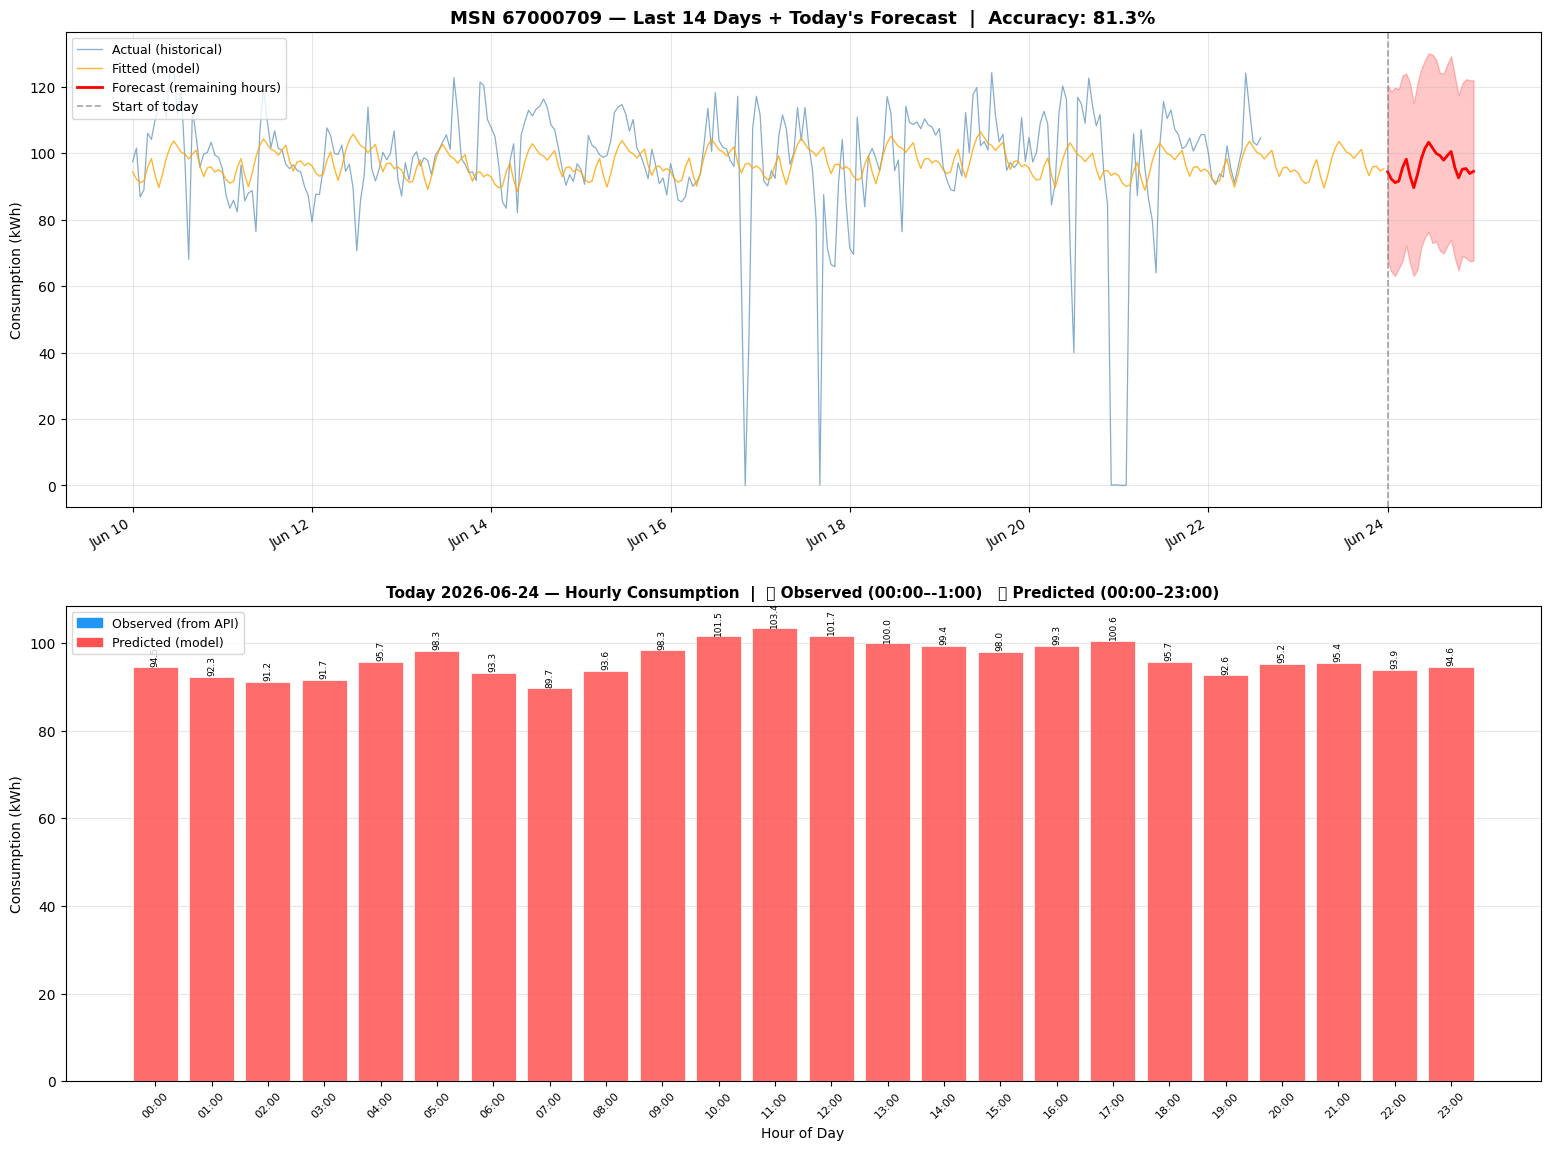

Plot saved → forecast_plot.png


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# ── Graph 1: Last 14 days + today's forecast ──────────────────────────────
ax = axes[0]
plot_start   = today_ts - pd.Timedelta(days=14)
df_hist_plot = df_train[df_train['ds'] >= plot_start]

# Get Prophet fitted values + forecast over the full plot window
fc_window = model.predict(
    pd.DataFrame({'ds': pd.date_range(plot_start,
                                       today_ts + pd.Timedelta(hours=23),
                                       freq='h')})
)
fc_window['yhat']       = fc_window['yhat'].clip(lower=0)
fc_window['yhat_lower'] = fc_window['yhat_lower'].clip(lower=0)
fc_window['yhat_upper'] = fc_window['yhat_upper'].clip(lower=0)

fc_past   = fc_window[fc_window['ds'] <  today_ts]
fc_future = fc_window[fc_window['ds'] >= today_ts]

# Historical actual
ax.plot(df_hist_plot['ds'], df_hist_plot['y'],
        color='steelblue', alpha=0.65, linewidth=0.9, label='Actual (historical)')

# Fitted line over history
ax.plot(fc_past['ds'], fc_past['yhat'],
        color='orange', linewidth=1, alpha=0.8, label='Fitted (model)')

# Today's observed dots
if len(df_today) > 0:
    ax.scatter(df_today['ds'], df_today['y'],
               color='green', zorder=6, s=40, label='Today (observed)')
    ax.plot(df_today['ds'], df_today['y'], color='green', linewidth=1.8, alpha=0.8)

# Today's forecast
ax.fill_between(fc_future['ds'], fc_future['yhat_lower'], fc_future['yhat_upper'],
                alpha=0.22, color='red')
ax.plot(fc_future['ds'], fc_future['yhat'],
        color='red', linewidth=2, label='Forecast (remaining hours)')

# Vertical line marking "now"
ax.axvline(today_ts, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='Start of today')

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.set_title(f'MSN {MSN} — Last 14 Days + Today\'s Forecast  |  Accuracy: {acc:.1f}%',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Consumption (kWh)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

# ── Graph 2: Today's 24-hour bar chart ────────────────────────────────────
ax2 = axes[1]
all_hours = list(range(24))

obs_vals  = {int(row['ds'].hour): row['y']    for _, row in df_today.iterrows()}
pred_vals = {int(row['ds'].hour): row['yhat'] for _, row in forecast.iterrows()}

bar_vals  = [obs_vals.get(h, pred_vals.get(h, 0)) for h in all_hours]
bar_color = ['#2196F3' if h in obs_vals else '#FF5252' for h in all_hours]

ax2.bar(all_hours, bar_vals, color=bar_color, edgecolor='white',
        linewidth=0.6, alpha=0.85, zorder=3)

# Annotate bar values
for h, v in zip(all_hours, bar_vals):
    if v > 0:
        ax2.text(h, v + 0.3, f'{v:.1f}', ha='center', va='bottom',
                 fontsize=6.5, rotation=90)

ax2.set_xticks(all_hours)
ax2.set_xticklabels([f'{h:02d}:00' for h in all_hours], rotation=45, fontsize=8)
ax2.set_title(
    f'Today {TODAY} — Hourly Consumption  |  '
    f'🔵 Observed (00:00–{last_obs_hour:02d}:00)   🔴 Predicted ({next_hour:02d}:00–23:00)',
    fontsize=11, fontweight='bold'
)
ax2.set_ylabel('Consumption (kWh)')
ax2.set_xlabel('Hour of Day')
ax2.grid(axis='y', alpha=0.3, zorder=0)

ax2.legend(handles=[
    mpatches.Patch(color='#2196F3', label='Observed (from API)'),
    mpatches.Patch(color='#FF5252', label='Predicted (model)'),
], fontsize=9)

plt.tight_layout(pad=2.5)
plt.savefig('forecast_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → forecast_plot.png')

In [16]:
# Observed hours (from API)
observed_json = {
    f'{int(row["ds"].hour):02d}:00': round(float(row['y']), 4)
    for _, row in df_today.iterrows()
}

# Predicted hours (with confidence range)
predicted_json = {
    f'{int(row["ds"].hour):02d}:00': {
        'predicted' : round(float(row['yhat']),       4),
        'lower_90'  : round(float(row['yhat_lower']), 4),
        'upper_90'  : round(float(row['yhat_upper']), 4),
    }
    for _, row in forecast.iterrows()
}

full_day_output = {
    'msn'       : MSN,
    'date'      : TODAY,
    'accuracy_%': round(acc, 2),
    'observed'  : observed_json,
    'predicted' : predicted_json,
}

print(json.dumps(full_day_output, indent=2))

{
  "msn": "67000709",
  "date": "2026-06-24",
  "accuracy_%": 81.28,
  "observed": {},
  "predicted": {
    "00:00": {
      "predicted": 94.4861,
      "lower_90": 66.6633,
      "upper_90": 120.0027
    },
    "01:00": {
      "predicted": 92.2903,
      "lower_90": 65.9816,
      "upper_90": 117.6091
    },
    "02:00": {
      "predicted": 91.2127,
      "lower_90": 64.2776,
      "upper_90": 117.1122
    },
    "03:00": {
      "predicted": 91.6525,
      "lower_90": 63.4814,
      "upper_90": 117.4655
    },
    "04:00": {
      "predicted": 95.7244,
      "lower_90": 68.6314,
      "upper_90": 120.5298
    },
    "05:00": {
      "predicted": 98.251,
      "lower_90": 70.487,
      "upper_90": 125.963
    },
    "06:00": {
      "predicted": 93.2524,
      "lower_90": 64.0932,
      "upper_90": 119.3075
    },
    "07:00": {
      "predicted": 89.6788,
      "lower_90": 62.5437,
      "upper_90": 115.7962
    },
    "08:00": {
      "predicted": 93.6277,
      "lower_90": 66.32

In [17]:
SHEETS = [
    '67000791', '67001560', '67000151', '67002178', '67002815',
    '67002177', '67000156', '67002462', '67002172', '67000135',
    '67000770', '67002538', '67001732', '67002321', '67002174',
    '67002465', '67000152', '67000771', '67001141', '67000769',
    '67000153', '67000767', '67000481', '67000607', '67002710',
    '67001582', '67000711', '67002049', '67000483', '67000443',
    '67000053', '67000768', '67000608', '67000442', '67001729',
    '67000095', '67000509', '67001836', '67000098', '67000522',
    '67001837','67006960','67000509'
]

# ── sMAPE: symmetric, handles zeros ───────────────────────────────────────
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    ratio = np.where(denom == 0, 0.0, np.abs(y_true - y_pred) / denom)
    return float(np.mean(ratio) * 100)

# ── Clean ──────────────────────────────────────────────────────────────────
def clean_df(df_raw):
    df = df_raw[df_raw['y'] >= 0].copy()
    nz = df['y'] > 0
    if nz.sum() > 20:
        Q1, Q3 = df.loc[nz, 'y'].quantile([0.25, 0.75])
        df = df[(df['y'] == 0) | (df['y'] <= Q3 + 3*(Q3-Q1))]
    df = df.set_index('ds').resample('h')['y'].mean().reset_index()
    df['y'] = df['y'].ffill(limit=1).fillna(0)
    return df

# ── Find best test window (avoids zero-heavy periods) ─────────────────────
def find_good_test_window(df, today_ts, test_days=7, search_back_days=90):
    for offset in range(0, search_back_days, 7):
        end    = today_ts - pd.Timedelta(days=offset)
        start  = end      - pd.Timedelta(days=test_days)
        window = df[(df['ds'] >= start) & (df['ds'] < end)]
        if len(window) >= 24 and (window['y'] > 0).mean() >= 0.5:
            return start, end, window
    end   = today_ts
    start = end - pd.Timedelta(days=test_days)
    return start, end, df[(df['ds'] >= start) & (df['ds'] < end)]

# ── Strategy 1: Naive same-hour same-DOW average ──────────────────────────
def naive_avg(df_train, df_test, n_weeks):
    preds = []
    for _, row in df_test.iterrows():
        ts   = row['ds']
        mask = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= ts - pd.Timedelta(weeks=n_weeks))
        )
        vals = df_train.loc[mask, 'y']
        preds.append(vals.mean() if len(vals) > 0 else df_train['y'].mean())
    return np.array(preds)

# ── Strategy 2: Naive same-hour same-DOW median (robust to spikes) ────────
def naive_median(df_train, df_test, n_weeks):
    preds = []
    for _, row in df_test.iterrows():
        ts   = row['ds']
        mask = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= ts - pd.Timedelta(weeks=n_weeks))
        )
        vals = df_train.loc[mask, 'y']
        preds.append(vals.median() if len(vals) > 0 else df_train['y'].median())
    return np.array(preds)

# ── Strategy 3: Exponentially weighted recent hours ───────────────────────
def weighted_recent(df_train, df_test, n_weeks=8, decay=0.85):
    preds = []
    for _, row in df_test.iterrows():
        ts     = row['ds']
        cutoff = ts - pd.Timedelta(weeks=n_weeks)
        mask   = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= cutoff)
        )
        subset = df_train.loc[mask].copy()
        if len(subset) == 0:
            preds.append(df_train['y'].mean())
            continue
        weeks_ago = (ts - subset['ds']).dt.days / 7.0
        weights   = decay ** weeks_ago
        preds.append(float(np.average(subset['y'].values, weights=weights.values)))
    return np.array(preds)

# ── Strategy 4: Prophet (variable recent window) ──────────────────────────
def prophet_predict(df_train, df_test, recent_days=None):
    train = df_train.copy()
    if recent_days:
        cutoff  = train['ds'].max() - pd.Timedelta(days=recent_days)
        trimmed = train[train['ds'] >= cutoff]
        if len(trimmed) >= 168:
            train = trimmed
    zero_pct = (train['y'] == 0).mean()
    mode     = 'additive' if zero_pct > 0.1 else 'multiplicative'
    m = Prophet(
        yearly_seasonality      = True,
        weekly_seasonality      = True,
        daily_seasonality       = True,
        seasonality_mode        = mode,
        changepoint_prior_scale = 0.05,
        seasonality_prior_scale = 5.0,
    )
    m.fit(train)
    fc = m.predict(df_test[['ds']])
    fc['yhat'] = fc['yhat'].clip(lower=0)
    return fc['yhat'].values

print('All strategy functions ready ✓')
print(f'Total consumers to evaluate: {len(SHEETS)}')

All strategy functions ready ✓
Total consumers to evaluate: 1


In [18]:
today_ts = pd.Timestamp(TODAY)
results  = []

for i, msn in enumerate(SHEETS):
    print(f"[{i+1}/{len(SHEETS)}] MSN {msn}", end=' ... ')
    try:
        df_c                          = clean_df(fetch_consumption_data(msn, TRAIN_START, TODAY))
        test_start, test_end, df_test = find_good_test_window(df_c, today_ts)
        df_train_c                    = df_c[df_c['ds'] < test_start].copy()

        if len(df_train_c) < 168 or len(df_test) < 24:
            print(f"SKIPPED (train={len(df_train_c)}, test={len(df_test)})")
            results.append({'MSN': msn, 'Accuracy_%': None, 'sMAPE_%': None,
                            'Strategy': 'skipped', 'Note': 'insufficient data'})
            continue

        y_true     = df_test['y'].values
        candidates = {}

        for wk in [2, 4, 6, 8]:
            try:
                p = naive_avg(df_train_c, df_test, n_weeks=wk)
                candidates[f'Naive-Avg-{wk}wk'] = (smape(y_true, p), p)
            except: pass

        for wk in [4, 8]:
            try:
                p = naive_median(df_train_c, df_test, n_weeks=wk)
                candidates[f'Naive-Med-{wk}wk'] = (smape(y_true, p), p)
            except: pass

        for wk in [4, 8]:
            try:
                p = weighted_recent(df_train_c, df_test, n_weeks=wk, decay=0.85)
                candidates[f'Weighted-{wk}wk']  = (smape(y_true, p), p)
            except: pass

        for days in [None, 90, 60, 30]:
            label = f'Prophet-{"Full" if days is None else str(days)+"d"}'
            try:
                p = prophet_predict(df_train_c, df_test, recent_days=days)
                candidates[label] = (smape(y_true, p), p)
            except: pass

        if not candidates:
            print("ALL FAILED")
            results.append({'MSN': msn, 'Accuracy_%': None, 'sMAPE_%': None,
                            'Strategy': 'all_failed', 'Note': 'all failed'})
            continue

        best_strategy        = min(candidates, key=lambda k: candidates[k][0])
        best_smape, best_pred = candidates[best_strategy]

        mae = mean_absolute_error(y_true, best_pred)
        rmse = float(np.sqrt(mean_squared_error(y_true, best_pred)))
        r2_c = r2_score(y_true, best_pred)
        acc_c = max(0.0, 100.0 - best_smape)

        results.append({
            'MSN'        : msn,
            'Accuracy_%' : round(acc_c,      2),
            'sMAPE_%'    : round(best_smape,  2),
            'MAE'        : round(mae,          4),
            'RMSE'       : round(rmse,         4),
            'R2'         : round(r2_c,         4),
            'Strategy'   : best_strategy,
            'TestWindow' : f"{test_start.date()} → {test_end.date()}",
            'Note'       : 'OK',
        })
        print(f"Accuracy={acc_c:.1f}%  [{best_strategy}]")

    except Exception as e:
        import traceback; traceback.print_exc()
        results.append({'MSN': msn, 'Accuracy_%': None, 'sMAPE_%': None,
                        'Strategy': 'error', 'Note': str(e)})

print("\nDone ✓")

[1/1] MSN 67000791 ... Accuracy=73.6%  [Prophet-Full]

Done ✓


In [19]:
df_results = pd.DataFrame(results)
valid      = df_results[df_results['Accuracy_%'].notna()].copy()

print("\n" + "=" * 100)
print("PERFORMANCE OF ALL CONSUMERS — sorted by Accuracy (highest first)")
print("=" * 100)
cols = ['MSN', 'Accuracy_%', 'sMAPE_%', 'MAE', 'RMSE', 'R2', 'Strategy', 'TestWindow']
print(valid.sort_values('Accuracy_%', ascending=False)[cols].to_string(index=False))
print("=" * 100)
print(f"\n  Consumers evaluated    : {len(valid)} / {len(SHEETS)}")
print(f"  Consumers >= 80%       : {(valid['Accuracy_%'] >= 80).sum()} / {len(valid)}")
print(f"  Consumers >= 60%       : {(valid['Accuracy_%'] >= 60).sum()} / {len(valid)}")
print(f"  Average Accuracy       : {valid['Accuracy_%'].mean():.2f}%")
print(f"  Average sMAPE          : {valid['sMAPE_%'].mean():.2f}%")
print(f"\n  Strategy breakdown:")
print(valid['Strategy'].value_counts().to_string())
print("=" * 100)


PERFORMANCE OF ALL CONSUMERS — sorted by Accuracy (highest first)
     MSN  Accuracy_%  sMAPE_%    MAE   RMSE     R2     Strategy              TestWindow
67000791       73.57    26.43 3.4734 5.0376 0.2557 Prophet-Full 2026-06-17 → 2026-06-24

  Consumers evaluated    : 1 / 1
  Consumers >= 80%       : 0 / 1
  Consumers >= 60%       : 1 / 1
  Average Accuracy       : 73.57%
  Average sMAPE          : 26.43%

  Strategy breakdown:
Strategy
Prophet-Full    1


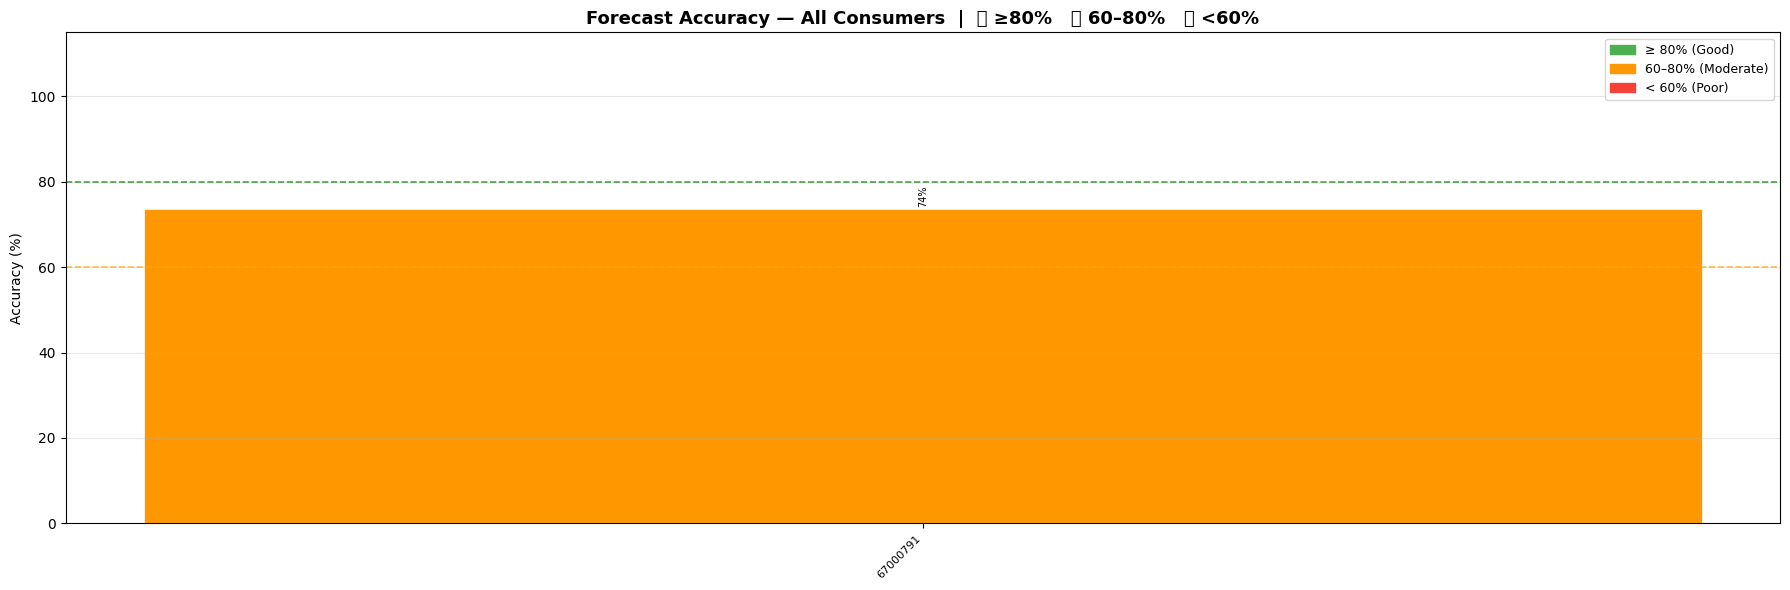

Chart saved → all_consumers_accuracy.png


In [20]:
# Visual bar chart of accuracy for all consumers
sorted_df = valid.sort_values('Accuracy_%', ascending=False).reset_index(drop=True)

colors = []
for a in sorted_df['Accuracy_%']:
    if a >= 80:
        colors.append('#4CAF50')   # green
    elif a >= 60:
        colors.append('#FF9800')   # orange
    else:
        colors.append('#F44336')   # red

fig, ax = plt.subplots(figsize=(18, 6))
bars = ax.bar(range(len(sorted_df)), sorted_df['Accuracy_%'], color=colors, edgecolor='white', linewidth=0.5)

# Reference lines
ax.axhline(80, color='green',  linestyle='--', linewidth=1.2, alpha=0.7, label='80% threshold')
ax.axhline(60, color='orange', linestyle='--', linewidth=1.2, alpha=0.7, label='60% threshold')

# Annotate each bar
for i, (a, bar) in enumerate(zip(sorted_df['Accuracy_%'], bars)):
    ax.text(i, a + 0.5, f'{a:.0f}%', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(range(len(sorted_df)))
ax.set_xticklabels(sorted_df['MSN'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 115)
ax.set_title('Forecast Accuracy — All Consumers  |  🟢 ≥80%   🟠 60–80%   🔴 <60%',
             fontsize=13, fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#4CAF50', label='≥ 80% (Good)'),
    mpatches.Patch(color='#FF9800', label='60–80% (Moderate)'),
    mpatches.Patch(color='#F44336', label='< 60% (Poor)'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('all_consumers_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → all_consumers_accuracy.png')

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# FUTURE DAY PREDICTOR — change only the CONFIG block
# ══════════════════════════════════════════════════════════════════════════════
import warnings, numpy as np, pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
warnings.filterwarnings('ignore')

# ── CONFIG ────────────────────────────────────────────────────────────────────
TARGET_MSN  = '67000509'          # ← change consumer here
TARGET_DATE = '2026-06-20'        # ← change forecast date here
TRAIN_START = '2025-01-01'
TODAY       = '2026-06-15'        # last available data date
# ─────────────────────────────────────────────────────────────────────────────

target_ts = pd.Timestamp(TARGET_DATE)
today_ts  = pd.Timestamp(TODAY)

# ── sMAPE ─────────────────────────────────────────────────────────────────────
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    ratio = np.where(denom == 0, 0.0, np.abs(y_true - y_pred) / denom)
    return float(np.mean(ratio) * 100)

# ── Clean ─────────────────────────────────────────────────────────────────────
def clean_df(df_raw):
    df = df_raw[df_raw['y'] >= 0].copy()
    nz = df['y'] > 0
    if nz.sum() > 20:
        Q1, Q3 = df.loc[nz, 'y'].quantile([0.25, 0.75])
        df = df[(df['y'] == 0) | (df['y'] <= Q3 + 3*(Q3 - Q1))]
    df = df.set_index('ds').resample('h')['y'].mean().reset_index()
    df['y'] = df['y'].ffill(limit=1).fillna(0)
    return df

# ── Find good validation window (avoids zero-heavy periods) ──────────────────
def find_good_test_window(df, ref_ts, test_days=7, search_back_days=90):
    for offset in range(0, search_back_days, 7):
        end    = ref_ts   - pd.Timedelta(days=offset)
        start  = end      - pd.Timedelta(days=test_days)
        window = df[(df['ds'] >= start) & (df['ds'] < end)]
        if len(window) >= 24 and (window['y'] > 0).mean() >= 0.5:
            return start, end, window
    end   = ref_ts
    start = end - pd.Timedelta(days=test_days)
    return start, end, df[(df['ds'] >= start) & (df['ds'] < end)]

# ── Strategy: Naive same-hour same-DOW average ───────────────────────────────
def naive_avg(df_train, df_test, n_weeks):
    preds = []
    for _, row in df_test.iterrows():
        ts   = row['ds']
        mask = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= ts - pd.Timedelta(weeks=n_weeks))
        )
        vals = df_train.loc[mask, 'y']
        preds.append(vals.mean() if len(vals) > 0 else df_train['y'].mean())
    return np.array(preds)

# ── Strategy: Naive same-hour same-DOW median ────────────────────────────────
def naive_median(df_train, df_test, n_weeks):
    preds = []
    for _, row in df_test.iterrows():
        ts   = row['ds']
        mask = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= ts - pd.Timedelta(weeks=n_weeks))
        )
        vals = df_train.loc[mask, 'y']
        preds.append(vals.median() if len(vals) > 0 else df_train['y'].median())
    return np.array(preds)

# ── Strategy: Exponentially weighted recent hours ─────────────────────────────
def weighted_recent(df_train, df_test, n_weeks=8, decay=0.85):
    preds = []
    for _, row in df_test.iterrows():
        ts     = row['ds']
        cutoff = ts - pd.Timedelta(weeks=n_weeks)
        mask   = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= cutoff)
        )
        subset = df_train.loc[mask].copy()
        if len(subset) == 0:
            preds.append(df_train['y'].mean())
            continue
        weeks_ago = (ts - subset['ds']).dt.days / 7.0
        weights   = decay ** weeks_ago
        preds.append(float(np.average(subset['y'].values, weights=weights.values)))
    return np.array(preds)

# ── Strategy: Prophet (variable training window) ──────────────────────────────
def prophet_predict(df_train, df_test, recent_days=None):
    train = df_train.copy()
    if recent_days:
        cutoff  = train['ds'].max() - pd.Timedelta(days=recent_days)
        trimmed = train[train['ds'] >= cutoff]
        if len(trimmed) >= 168:
            train = trimmed
    mode = 'additive' if (train['y'] == 0).mean() > 0.1 else 'multiplicative'
    m = Prophet(
        yearly_seasonality      = True,
        weekly_seasonality      = True,
        daily_seasonality       = True,
        seasonality_mode        = mode,
        changepoint_prior_scale = 0.05,
        seasonality_prior_scale = 5.0,
    )
    m.fit(train)
    fc = m.predict(df_test[['ds']])
    fc['yhat'] = fc['yhat'].clip(lower=0)
    return fc['yhat'].values

# ══════════════════════════════════════════════════════════════════════════════
# STEP 1 — Fetch + clean training data (Jan 2025 → today)
# ══════════════════════════════════════════════════════════════════════════════
print(f'Fetching data for MSN {TARGET_MSN}  ({TRAIN_START} → {TODAY}) …')
df_raw   = fetch_consumption_data(TARGET_MSN, TRAIN_START, TODAY)
df_clean = clean_df(df_raw)
print(f'  {len(df_clean)} hourly records loaded')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 2 — Evaluate accuracy using best strategy (on a validation window)
# ══════════════════════════════════════════════════════════════════════════════
val_start, val_end, df_val = find_good_test_window(df_clean, today_ts)
df_train_eval = df_clean[df_clean['ds'] < val_start].copy()

print(f'\nValidation window : {val_start.date()} → {val_end.date()}')
print(f'Training rows     : {len(df_train_eval)}')

y_true     = df_val['y'].values
candidates = {}

for wk in [2, 4, 6, 8]:
    try:
        p = naive_avg(df_train_eval, df_val, n_weeks=wk)
        candidates[f'Naive-Avg-{wk}wk'] = (smape(y_true, p), p)
    except: pass

for wk in [4, 8]:
    try:
        p = naive_median(df_train_eval, df_val, n_weeks=wk)
        candidates[f'Naive-Med-{wk}wk'] = (smape(y_true, p), p)
    except: pass

for wk in [4, 8]:
    try:
        p = weighted_recent(df_train_eval, df_val, n_weeks=wk, decay=0.85)
        candidates[f'Weighted-{wk}wk']  = (smape(y_true, p), p)
    except: pass

for days in [None, 90, 60, 30]:
    label = f'Prophet-{"Full" if days is None else str(days)+"d"}'
    try:
        p = prophet_predict(df_train_eval, df_val, recent_days=days)
        candidates[label] = (smape(y_true, p), p)
    except: pass

best_strategy    = min(candidates, key=lambda k: candidates[k][0])
best_val_smape   = candidates[best_strategy][0]
acc              = max(0.0, 100.0 - best_val_smape)

print(f'\nBest strategy : {best_strategy}')
print(f'Accuracy      : {acc:.2f}%  (sMAPE={best_val_smape:.2f}%)')

# ══════════════════════════════════════════════════════════════════════════════
# STEP 3 — Predict all 24 hours of TARGET_DATE using the winning strategy
#           Train on the FULL dataset up to today (no validation split)
# ══════════════════════════════════════════════════════════════════════════════
df_train_full = df_clean.copy()   # all data up to today

# Build a 24-row test frame for the target date
future_hours = pd.DataFrame({
    'ds': [target_ts + pd.Timedelta(hours=h) for h in range(24)],
    'y' : 0.0   # placeholder, not used for prediction
})

print(f'\nGenerating 24-hour forecast for {TARGET_DATE} using [{best_strategy}] …')

if 'Prophet' in best_strategy:
    recent_days = None
    if '90d'  in best_strategy: recent_days = 90
    elif '60d' in best_strategy: recent_days = 60
    elif '30d' in best_strategy: recent_days = 30
    y_pred_future = prophet_predict(df_train_full, future_hours, recent_days=recent_days)

elif 'Naive-Avg' in best_strategy:
    wk = int(best_strategy.split('-')[-1].replace('wk',''))
    y_pred_future = naive_avg(df_train_full, future_hours, n_weeks=wk)

elif 'Naive-Med' in best_strategy:
    wk = int(best_strategy.split('-')[-1].replace('wk',''))
    y_pred_future = naive_median(df_train_full, future_hours, n_weeks=wk)

elif 'Weighted' in best_strategy:
    wk = int(best_strategy.split('-')[-1].replace('wk',''))
    y_pred_future = weighted_recent(df_train_full, future_hours, n_weeks=wk, decay=0.85)

# ══════════════════════════════════════════════════════════════════════════════
# STEP 4 — Print results
# ══════════════════════════════════════════════════════════════════════════════
print()
print('=' * 52)
print(f'  FORECAST — MSN {TARGET_MSN}  |  {TARGET_DATE}')
print('=' * 52)
print(f'  Strategy  : {best_strategy}')
print(f'  Accuracy  : {acc:.2f}%')
print('-' * 52)
print(f'  {"Hour":>6}   {"Predicted":>12}')
print('-' * 52)
for h, val in enumerate(y_pred_future):
    print(f'  {h:02d}:00   {val:12.4f}')
print('-' * 52)
print(f'  Day total : {y_pred_future.sum():.4f}')
print('=' * 52)

# Save to dataframe for CODE 2
df_forecast_june16 = pd.DataFrame({
    'hour'     : list(range(24)),
    'ds'       : future_hours['ds'].values,
    'predicted': y_pred_future
})

Fetching data for MSN 67000509  (2025-01-01 → 2026-06-15) …
  8651 hourly records loaded

Validation window : 2026-06-08 → 2026-06-15
Training rows     : 8459

Best strategy : Naive-Med-4wk
Accuracy      : 30.93%  (sMAPE=69.07%)

Generating 24-hour forecast for 2026-06-20 using [Naive-Med-4wk] …

  FORECAST — MSN 67000509  |  2026-06-20
  Strategy  : Naive-Med-4wk
  Accuracy  : 30.93%
----------------------------------------------------
    Hour      Predicted
----------------------------------------------------
  00:00         1.0500
  01:00         1.0500
  02:00         1.0500
  03:00         1.0500
  04:00         1.0500
  05:00         0.8500
  06:00         0.5000
  07:00         0.8000
  08:00        14.5500
  09:00        20.4000
  10:00         5.8000
  11:00         9.7000
  12:00         5.6500
  13:00         1.5000
  14:00         6.7500
  15:00         8.2000
  16:00         3.5000
  17:00         9.7500
  18:00         4.8000
  19:00         1.7000
  20:00         0.9500

Fetching actual for 2026-06-12 …
Predicting 2026-06-20 using [Naive-Med-4wk] …


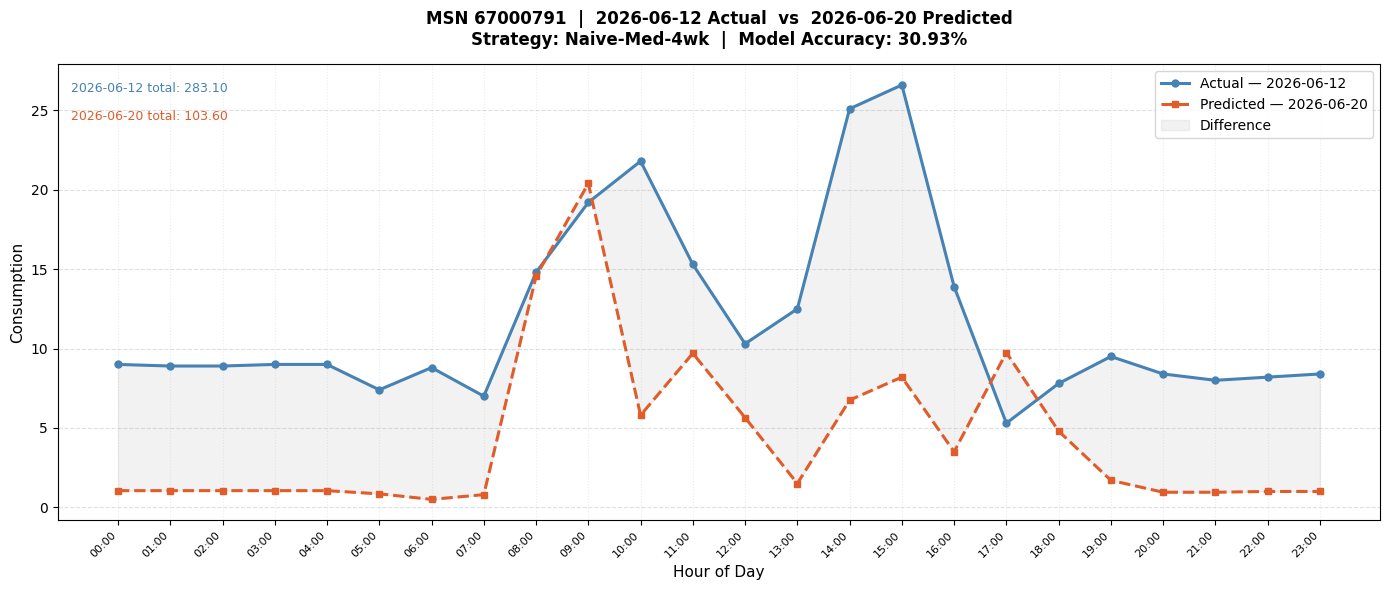

Graph saved → MSN_67000791_2026-06-12_vs_2026-06-20.png


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPARISON GRAPH — Any two dates: one actual + one predicted
# Run this after CODE 1 (uses df_train_full, best_strategy, acc from above)
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt

# ── CONFIG ────────────────────────────────────────────────────────────────────
TARGET_MSN    = '67000791'      # ← consumer
ACTUAL_DATE   = '2026-06-12'   # ← date to pull actual values from API
FORECAST_DATE = '2026-06-20'   # ← date to predict
# ─────────────────────────────────────────────────────────────────────────────

actual_ts   = pd.Timestamp(ACTUAL_DATE)
forecast_ts = pd.Timestamp(FORECAST_DATE)
hours       = list(range(24))

# ── Fetch actual from API ─────────────────────────────────────────────────────
print(f'Fetching actual for {ACTUAL_DATE} …')
df_actual_raw = fetch_consumption_data(TARGET_MSN, ACTUAL_DATE, ACTUAL_DATE)
all_hours_df  = pd.DataFrame({'ds': [actual_ts + pd.Timedelta(hours=h) for h in hours]})
df_actual     = all_hours_df.merge(df_actual_raw, on='ds', how='left')
df_actual['y'] = df_actual['y'].fillna(0).clip(lower=0)
actual_vals    = df_actual['y'].values

# ── Predict forecast date using winning strategy from CODE 1 ──────────────────
print(f'Predicting {FORECAST_DATE} using [{best_strategy}] …')
future_hours = pd.DataFrame({
    'ds': [forecast_ts + pd.Timedelta(hours=h) for h in hours],
    'y' : 0.0
})

if 'Prophet' in best_strategy:
    recent_days = None
    if '90d'  in best_strategy: recent_days = 90
    elif '60d' in best_strategy: recent_days = 60
    elif '30d' in best_strategy: recent_days = 30
    forecast_vals = prophet_predict(df_train_full, future_hours, recent_days=recent_days)
elif 'Naive-Avg' in best_strategy:
    wk = int(best_strategy.split('-')[-1].replace('wk',''))
    forecast_vals = naive_avg(df_train_full, future_hours, n_weeks=wk)
elif 'Naive-Med' in best_strategy:
    wk = int(best_strategy.split('-')[-1].replace('wk',''))
    forecast_vals = naive_median(df_train_full, future_hours, n_weeks=wk)
elif 'Weighted' in best_strategy:
    wk = int(best_strategy.split('-')[-1].replace('wk',''))
    forecast_vals = weighted_recent(df_train_full, future_hours, n_weeks=wk, decay=0.85)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(hours, actual_vals,
        color='steelblue', linewidth=2.2, marker='o', markersize=5,
        label=f'Actual — {ACTUAL_DATE}', zorder=3)

ax.plot(hours, forecast_vals,
        color='#E05C2A', linewidth=2.2, marker='s', markersize=5,
        linestyle='--', label=f'Predicted — {FORECAST_DATE}', zorder=3)

ax.fill_between(hours, actual_vals, forecast_vals,
                alpha=0.10, color='gray', label='Difference')

ax.set_xticks(hours)
ax.set_xticklabels([f'{h:02d}:00' for h in hours], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Consumption', fontsize=11)
ax.set_xlabel('Hour of Day', fontsize=11)
ax.set_title(
    f'MSN {TARGET_MSN}  |  {ACTUAL_DATE} Actual  vs  {FORECAST_DATE} Predicted\n'
    f'Strategy: {best_strategy}  |  Model Accuracy: {acc:.2f}%',
    fontsize=12, fontweight='bold', pad=14
)
ax.legend(fontsize=10, loc='upper right')
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.grid(axis='x', linestyle=':', alpha=0.25)

ax.annotate(f'{ACTUAL_DATE} total: {actual_vals.sum():.2f}',
            xy=(0.01, 0.96), xycoords='axes fraction', fontsize=9, color='steelblue', va='top')
ax.annotate(f'{FORECAST_DATE} total: {forecast_vals.sum():.2f}',
            xy=(0.01, 0.90), xycoords='axes fraction', fontsize=9, color='#E05C2A', va='top')

plt.tight_layout()
plt.savefig(f'MSN_{TARGET_MSN}_{ACTUAL_DATE}_vs_{FORECAST_DATE}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Graph saved → MSN_{TARGET_MSN}_{ACTUAL_DATE}_vs_{FORECAST_DATE}.png')


In [ ]:
def robust_seasonal_naive(df_train, df_test, n_weeks=8, min_samples=4):
    preds = []
    for _, row in df_test.iterrows():
        ts   = row['ds']
        mask = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= ts - pd.Timedelta(weeks=n_weeks))
        )
        vals = df_train.loc[mask, 'y'].values

        if len(vals) < min_samples:
            preds.append(np.median(vals) if len(vals) > 0 else df_train['y'].median())
            continue

        q1, q3 = np.percentile(vals, [25, 75])
        iqr    = q3 - q1
        if iqr == 0:
            preds.append(np.mean(vals))
            continue

        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        clean = vals[(vals >= lower) & (vals <= upper)]

        preds.append(float(np.mean(clean)) if len(clean) > 0 else float(np.median(vals)))

    return np.array(preds)

In [ ]:
for wk in [4, 8]:
    try:
        p = robust_seasonal_naive(df_train_c, df_test, n_weeks=wk)
        candidates[f'Robust-Seasonal-{wk}wk'] = (smape(y_true, p), p)
    except: pass

In [ ]:
SHEETS = [
    '67000791', '67001560', '67000151', '67002178', '67002815',
    '67002177', '67000156', '67002462', '67002172', '67000135',
    '67000770', '67002538', '67001732', '67002321', '67002174',
    '67002465', '67000152', '67000771', '67001141', '67000769',
    '67000153', '67000767', '67000481', '67000607', '67002710',
    '67001582', '67000711', '67002049', '67000483', '67000443',
    '67000053', '67000768', '67000608', '67000442', '67001729',
    '67000095', '67000509', '67001836', '67000098', '67000522',
    '67001837','67006960','67000509'
]

# ── sMAPE: symmetric, handles zeros ───────────────────────────────────────
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    ratio = np.where(denom == 0, 0.0, np.abs(y_true - y_pred) / denom)
    return float(np.mean(ratio) * 100)

# ── Clean ──────────────────────────────────────────────────────────────────
def clean_df(df_raw):
    df = df_raw[df_raw['y'] >= 0].copy()
    nz = df['y'] > 0
    if nz.sum() > 20:
        Q1, Q3 = df.loc[nz, 'y'].quantile([0.25, 0.75])
        df = df[(df['y'] == 0) | (df['y'] <= Q3 + 3*(Q3-Q1))]
    df = df.set_index('ds').resample('h')['y'].mean().reset_index()
    df['y'] = df['y'].ffill(limit=1).fillna(0)
    return df

# ── Find best test window (avoids zero-heavy periods) ─────────────────────
def find_good_test_window(df, today_ts, test_days=7, search_back_days=90):
    for offset in range(0, search_back_days, 7):
        end    = today_ts - pd.Timedelta(days=offset)
        start  = end      - pd.Timedelta(days=test_days)
        window = df[(df['ds'] >= start) & (df['ds'] < end)]
        if len(window) >= 24 and (window['y'] > 0).mean() >= 0.5:
            return start, end, window
    end   = today_ts
    start = end - pd.Timedelta(days=test_days)
    return start, end, df[(df['ds'] >= start) & (df['ds'] < end)]

# ── Strategy 1: Naive same-hour same-DOW average ──────────────────────────
def naive_avg(df_train, df_test, n_weeks):
    preds = []
    for _, row in df_test.iterrows():
        ts   = row['ds']
        mask = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= ts - pd.Timedelta(weeks=n_weeks))
        )
        vals = df_train.loc[mask, 'y']
        preds.append(vals.mean() if len(vals) > 0 else df_train['y'].mean())
    return np.array(preds)

# ── Strategy 2: Naive same-hour same-DOW median (robust to spikes) ────────
def naive_median(df_train, df_test, n_weeks):
    preds = []
    for _, row in df_test.iterrows():
        ts   = row['ds']
        mask = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= ts - pd.Timedelta(weeks=n_weeks))
        )
        vals = df_train.loc[mask, 'y']
        preds.append(vals.median() if len(vals) > 0 else df_train['y'].median())
    return np.array(preds)

# ── Strategy 3: Exponentially weighted recent hours ───────────────────────
def weighted_recent(df_train, df_test, n_weeks=8, decay=0.85):
    preds = []
    for _, row in df_test.iterrows():
        ts     = row['ds']
        cutoff = ts - pd.Timedelta(weeks=n_weeks)
        mask   = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= cutoff)
        )
        subset = df_train.loc[mask].copy()
        if len(subset) == 0:
            preds.append(df_train['y'].mean())
            continue
        weeks_ago = (ts - subset['ds']).dt.days / 7.0
        weights   = decay ** weeks_ago
        preds.append(float(np.average(subset['y'].values, weights=weights.values)))
    return np.array(preds)

# ── Strategy 4: Prophet (variable recent window) ──────────────────────────
def prophet_predict(df_train, df_test, recent_days=None):
    train = df_train.copy()
    if recent_days:
        cutoff  = train['ds'].max() - pd.Timedelta(days=recent_days)
        trimmed = train[train['ds'] >= cutoff]
        if len(trimmed) >= 168:
            train = trimmed
    zero_pct = (train['y'] == 0).mean()
    mode     = 'additive' if zero_pct > 0.1 else 'multiplicative'
    m = Prophet(
        yearly_seasonality      = True,
        weekly_seasonality      = True,
        daily_seasonality       = True,
        seasonality_mode        = mode,
        changepoint_prior_scale = 0.05,
        seasonality_prior_scale = 5.0,
    )
    m.fit(train)
    fc = m.predict(df_test[['ds']])
    fc['yhat'] = fc['yhat'].clip(lower=0)
    return fc['yhat'].values

# ── Strategy 5: Robust seasonal-naive with per-slot IQR clipping ──────────
# Guards against a single freak week (meter fault, one-off event) skewing
# a slot's prediction. NOTE: needs a MAJORITY of clean weeks in the lookback
# to work — if 3+ of 8 weeks are themselves irregular, this degrades toward
# plain-mean behavior, so Naive-Median remains the safer fallback for badly
# contaminated consumers.
def robust_seasonal_naive(df_train, df_test, n_weeks=8, min_samples=4):
    preds = []
    for _, row in df_test.iterrows():
        ts   = row['ds']
        mask = (
            (df_train['ds'].dt.dayofweek == ts.dayofweek) &
            (df_train['ds'].dt.hour      == ts.hour) &
            (df_train['ds'] >= ts - pd.Timedelta(weeks=n_weeks))
        )
        vals = df_train.loc[mask, 'y'].values

        if len(vals) < min_samples:
            preds.append(np.median(vals) if len(vals) > 0 else df_train['y'].median())
            continue

        q1, q3 = np.percentile(vals, [25, 75])
        iqr    = q3 - q1
        if iqr == 0:
            preds.append(np.mean(vals))
            continue

        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        clean = vals[(vals >= lower) & (vals <= upper)]

        preds.append(float(np.mean(clean)) if len(clean) > 0 else float(np.median(vals)))
    return np.array(preds)

print('All strategy functions ready ✓')
print(f'Total consumers to evaluate: {len(SHEETS)}')

All strategy functions ready ✓
Total consumers to evaluate: 43


In [ ]:
today_ts = pd.Timestamp(TODAY)
results  = []

for i, msn in enumerate(SHEETS):
    print(f"[{i+1}/{len(SHEETS)}] MSN {msn}", end=' ... ')
    try:
        df_c                          = clean_df(fetch_consumption_data(msn, TRAIN_START, TODAY))
        test_start, test_end, df_test = find_good_test_window(df_c, today_ts)
        df_train_c                    = df_c[df_c['ds'] < test_start].copy()

        if len(df_train_c) < 168 or len(df_test) < 24:
            print(f"SKIPPED (train={len(df_train_c)}, test={len(df_test)})")
            results.append({'MSN': msn, 'Accuracy_%': None, 'sMAPE_%': None,
                            'Strategy': 'skipped', 'Note': 'insufficient data'})
            continue

        y_true     = df_test['y'].values
        candidates = {}

        for wk in [2, 4, 6, 8]:
            try:
                p = naive_avg(df_train_c, df_test, n_weeks=wk)
                candidates[f'Naive-Avg-{wk}wk'] = (smape(y_true, p), p)
            except: pass

        for wk in [4, 8]:
            try:
                p = naive_median(df_train_c, df_test, n_weeks=wk)
                candidates[f'Naive-Med-{wk}wk'] = (smape(y_true, p), p)
            except: pass

        for wk in [4, 8]:
            try:
                p = weighted_recent(df_train_c, df_test, n_weeks=wk, decay=0.85)
                candidates[f'Weighted-{wk}wk']  = (smape(y_true, p), p)
            except: pass

        for wk in [4, 8]:
            try:
                p = robust_seasonal_naive(df_train_c, df_test, n_weeks=wk)
                candidates[f'Robust-Seasonal-{wk}wk'] = (smape(y_true, p), p)
            except: pass

        for days in [None, 90, 60, 30]:
            label = f'Prophet-{"Full" if days is None else str(days)+"d"}'
            try:
                p = prophet_predict(df_train_c, df_test, recent_days=days)
                candidates[label] = (smape(y_true, p), p)
            except: pass

        if not candidates:
            print("ALL FAILED")
            results.append({'MSN': msn, 'Accuracy_%': None, 'sMAPE_%': None,
                            'Strategy': 'all_failed', 'Note': 'all failed'})
            continue

        best_strategy        = min(candidates, key=lambda k: candidates[k][0])
        best_smape, best_pred = candidates[best_strategy]

        mae = mean_absolute_error(y_true, best_pred)
        rmse = float(np.sqrt(mean_squared_error(y_true, best_pred)))
        r2_c = r2_score(y_true, best_pred)
        acc_c = max(0.0, 100.0 - best_smape)

        results.append({
            'MSN'        : msn,
            'Accuracy_%' : round(acc_c,      2),
            'sMAPE_%'    : round(best_smape,  2),
            'MAE'        : round(mae,          4),
            'RMSE'       : round(rmse,         4),
            'R2'         : round(r2_c,         4),
            'Strategy'   : best_strategy,
            'TestWindow' : f"{test_start.date()} → {test_end.date()}",
            'Note'       : 'OK',
        })
        print(f"Accuracy={acc_c:.1f}%  [{best_strategy}]")

    except Exception as e:
        import traceback; traceback.print_exc()
        results.append({'MSN': msn, 'Accuracy_%': None, 'sMAPE_%': None,
                        'Strategy': 'error', 'Note': str(e)})

print("\nDone ✓")

[1/43] MSN 67000791 ... Accuracy=60.7%  [Naive-Avg-8wk]
[2/43] MSN 67001560 ... Accuracy=82.2%  [Naive-Avg-8wk]
[3/43] MSN 67000151 ... Accuracy=49.8%  [Robust-Seasonal-8wk]
[4/43] MSN 67002178 ... Accuracy=58.2%  [Naive-Avg-2wk]
[5/43] MSN 67002815 ... Accuracy=79.4%  [Naive-Avg-8wk]
[6/43] MSN 67002177 ... Accuracy=95.2%  [Naive-Avg-2wk]
[7/43] MSN 67000156 ... Accuracy=69.1%  [Robust-Seasonal-8wk]
[8/43] MSN 67002462 ... Accuracy=84.7%  [Naive-Med-8wk]
[9/43] MSN 67002172 ... Accuracy=80.9%  [Prophet-Full]
[10/43] MSN 67000135 ... Accuracy=76.0%  [Weighted-4wk]
[11/43] MSN 67000770 ... Accuracy=90.3%  [Naive-Med-4wk]
[12/43] MSN 67002538 ... Accuracy=73.9%  [Robust-Seasonal-8wk]
[13/43] MSN 67001732 ... Accuracy=89.3%  [Naive-Med-4wk]
[14/43] MSN 67002321 ... Accuracy=59.5%  [Weighted-8wk]
[15/43] MSN 67002174 ... Accuracy=94.3%  [Prophet-Full]
[16/43] MSN 67002465 ... Accuracy=78.9%  [Naive-Med-8wk]
[17/43] MSN 67000152 ... Accuracy=78.7%  [Naive-Med-8wk]
[18/43] MSN 67000771 ... A